In [32]:
import faraway.datasets.coagulation
import polars as pl
import matplotlib.pyplot as plt
coagulation = faraway.datasets.coagulation.load()

In [33]:
coagulation.head(3)

,coag,diet
1,62,A
2,60,A
3,63,A


Question

In the faraway package, we have a data set named "worldcup" giving various R: data on players from the 2010 World Cup. The variable "Time" tells us the time played in minutes by the various players. 

After you have installed and loaded the faraway package, find the average time played by using the command

 mean(worldcup$Time)

What is the average time played? You may round to 2 or three places after the decimal point. 



In [18]:
import requests
import pyreadr

url = "https://raw.githubusercontent.com/julianfaraway/faraway/main/data/worldcup.rda"

response = requests.get(url)
response.raise_for_status()

with open("worldcup.rda", "wb") as f:
    f.write(response.content)

result = pyreadr.read_r("worldcup.rda")

print(result.keys())

df = result["worldcup"]

odict_keys(['worldcup'])


In [25]:
df = df.reset_index().rename(columns={"rownames":"Palyers"})

In [29]:
df['Time'].mean()

np.float64(208.86386554621848)

### Course plot

In [36]:
type(coagulation)

pandas.DataFrame

{'whiskers': [<matplotlib.lines.Line2D at 0x22c69f75550>,
 'caps': [<matplotlib.lines.Line2D at 0x22c69f757f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x22c69f75400>],
 'medians': [<matplotlib.lines.Line2D at 0x22c69f75a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x22c69f75be0>],
 'means': []}

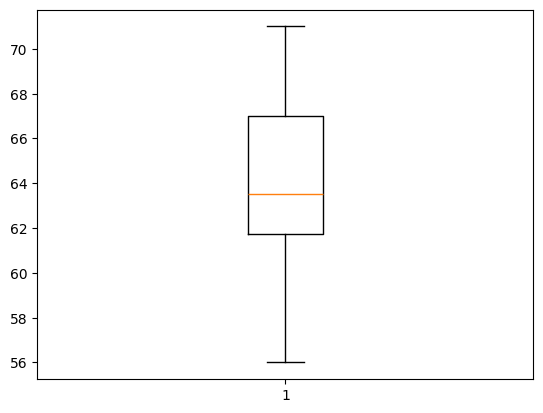

In [38]:
plt.boxplot(coagulation['coag'])

In [40]:
coagulation['diet'].unique()

<StringArray>
['A', 'B', 'C', 'D']
Length: 4, dtype: str

In [43]:
coagulation.groupby("diet").count()

,coag
diet,
A,4
B,6
C,6
D,8


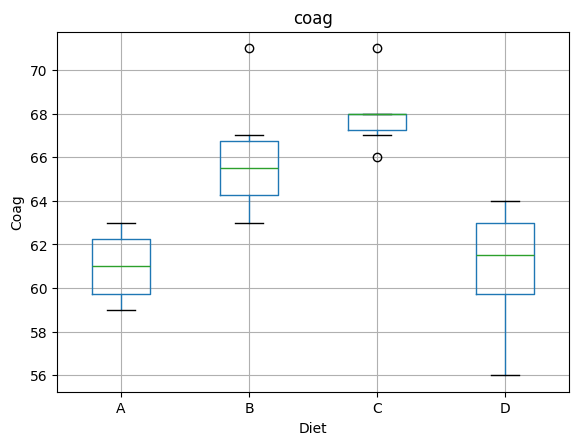

In [46]:
coagulation.boxplot(column="coag", by="diet")
plt.xlabel("Diet")
plt.ylabel("Coag")
plt.suptitle("")
plt.show()

In [47]:
coagulation.groupby("diet")["coag"]